In [1]:
# ============================================================
# F7 Week 04 — Black-Box Optimisation (MAXIMISE)
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================================================

# -----------------------------
# Imports (all at top)
# -----------------------------
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors

In [2]:
# ============================================================
# 0) CONFIG
# ============================================================
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

INPUTS_PATH = "data/F7/initial_inputs.npy"
OUTPUTS_PATH = "data/F7/initial_outputs.npy"

# If you're running in the course workspace where files are in /mnt/data,
# uncomment these overrides:
# INPUTS_PATH = "/mnt/data/initial_inputs.npy"
# OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

RANDOM_SEED = 42

# Candidate generation
N_GLOBAL = 20000              # global random candidates
N_LOCAL = 6000                # local candidates around current best
LOCAL_SIGMA = 0.08            # perturbation scale (tune if needed)

# Acquisition (EI)
XI = 0.01                     # small exploration bias (EI "jitter")

# Models
GP_RESTARTS = 8               # increase if you want better GP kernel fitting
RF_TREES = 600
RF_MIN_LEAF = 2

GBM_ENSEMBLE_SIZE = 10
GBM_ESTIMATORS = 400
GBM_LR = 0.05
GBM_MAX_DEPTH = 3
GBM_SUBSAMPLE = 0.8

# Diversity guard (avoid near-duplicates)
MIN_DIST = 1e-3               # min distance to existing points

In [3]:
# ============================================================
# 1) LOAD
# ============================================================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

assert X.ndim == 2 and X.shape[1] == 6, "F7 expects X to be (n,6)"
assert y.ndim == 1 and y.shape[0] == X.shape[0], "y must be (n,) matching X rows"

n, d = X.shape
best_idx = int(np.argmax(y))
x_best = X[best_idx]
y_best = float(np.max(y))

print(f"[LOAD] n={n}, d={d}")
print(f"[LOAD] current best y={y_best:.6f} at idx={best_idx}")
print(f"[LOAD] x_best={x_best}")

[LOAD] n=32, d=6
[LOAD] current best y=1.565071 at idx=30
[LOAD] x_best=[0.       0.425878 0.225301 0.207625 0.373905 0.758381]


In [4]:
# ============================================================
# 2) SURROGATE
# ============================================================

# --- GP with standardisation (recommended)
X_scaler = StandardScaler()
y_scaler = StandardScaler()

Xs = X_scaler.fit_transform(X)
ys = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

kernel = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-8,
    normalize_y=False,
    n_restarts_optimizer=GP_RESTARTS,
    random_state=RANDOM_SEED,
)
gp.fit(Xs, ys)

# --- RF (uncertainty from tree spread)
rf = RandomForestRegressor(
    n_estimators=RF_TREES,
    min_samples_leaf=RF_MIN_LEAF,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
rf.fit(X, y)

# --- GBM ensemble (uncertainty from ensemble spread)
gbm_ens = []
for k in range(GBM_ENSEMBLE_SIZE):
    m = GradientBoostingRegressor(
        random_state=RANDOM_SEED + 100 + k,
        n_estimators=GBM_ESTIMATORS,
        learning_rate=GBM_LR,
        max_depth=GBM_MAX_DEPTH,
        subsample=GBM_SUBSAMPLE,
    )
    m.fit(X, y)
    gbm_ens.append(m)

print("[SURROGATE] GP kernel:", gp.kernel_)


[SURROGATE] GP kernel: 0.785**2 * RBF(length_scale=[2.75, 2.69, 100, 18, 0.673, 0.242]) + WhiteKernel(noise_level=1e-06)


In [5]:
# ============================================================
# 3) ACQUISITION (Blended Expected Improvement)
# ============================================================

def expected_improvement(mu: np.ndarray, sigma: np.ndarray, best: float, xi: float = 0.0) -> np.ndarray:
    """
    EI for MAXIMISATION.
    EI = (mu - best - xi) * Phi(Z) + sigma * phi(Z)
    where Z = (mu - best - xi) / sigma
    """
    sigma = np.maximum(sigma, 1e-12)
    improvement = mu - best - xi
    Z = improvement / sigma
    return improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

rng = np.random.default_rng(RANDOM_SEED)

# Global candidates
cand_global = rng.random((N_GLOBAL, d))

# Local candidates near best point
cand_local = np.clip(x_best + rng.normal(0, LOCAL_SIGMA, size=(N_LOCAL, d)), 0.0, 1.0)

# Combine
CAND = np.vstack([cand_global, cand_local])

# --- GP predictions
CANDs = X_scaler.transform(CAND)
mu_gp_s, std_gp_s = gp.predict(CANDs, return_std=True)
mu_gp = y_scaler.inverse_transform(mu_gp_s.reshape(-1, 1)).ravel()
std_gp = std_gp_s * y_scaler.scale_[0]

# --- RF predictions (tree spread)
tree_preds = np.stack([t.predict(CAND) for t in rf.estimators_], axis=0)
mu_rf = tree_preds.mean(axis=0)
std_rf = tree_preds.std(axis=0)

# --- GBM ensemble predictions (ensemble spread)
ens_preds = np.stack([m.predict(CAND) for m in gbm_ens], axis=0)
mu_gbm = ens_preds.mean(axis=0)
std_gbm = ens_preds.std(axis=0)

# EI per model + blended EI
ei_gp = expected_improvement(mu_gp, std_gp, y_best, XI)
ei_rf = expected_improvement(mu_rf, std_rf, y_best, XI)
ei_gbm = expected_improvement(mu_gbm, std_gbm, y_best, XI)

ei_blend = (ei_gp + ei_rf + ei_gbm) / 3.0

# Diversity constraint: avoid points too close to existing samples
nn = NearestNeighbors(n_neighbors=1).fit(X)
dist = nn.kneighbors(CAND, return_distance=True)[0].ravel()

valid = dist > MIN_DIST
if not np.any(valid):
    print("[ACQ] WARNING: all candidates too close to existing points; relaxing constraint.")
    valid = np.ones_like(dist, dtype=bool)

best_cand_idx = int(np.argmax(np.where(valid, ei_blend, -np.inf)))
x_next = CAND[best_cand_idx]
x_next_dist = float(dist[best_cand_idx])
x_next_ei = float(ei_blend[best_cand_idx])

print(f"[ACQ] Best blended EI={x_next_ei:.6f} | min-dist-to-data={x_next_dist:.6f}")
print(f"[ACQ] x_next = {x_next}")



[ACQ] Best blended EI=0.021298 | min-dist-to-data=0.557331
[ACQ] x_next = [0.02152333 0.9818603  0.75816397 0.53787378 0.26214007 0.73044208]


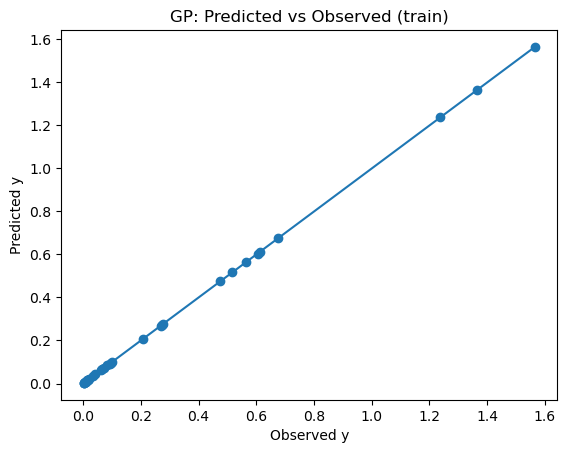

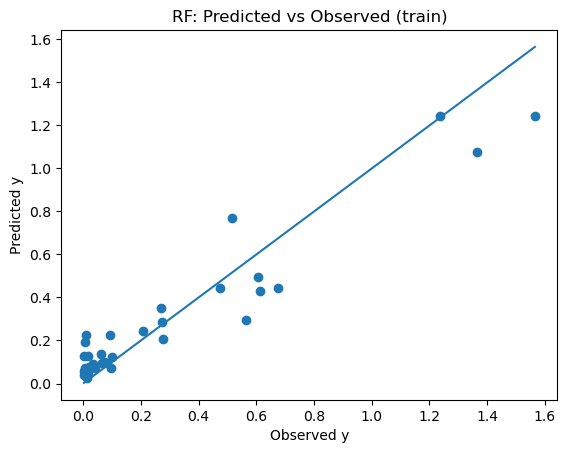

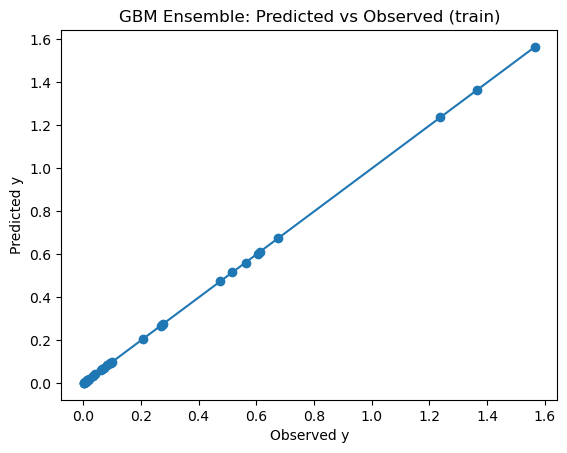

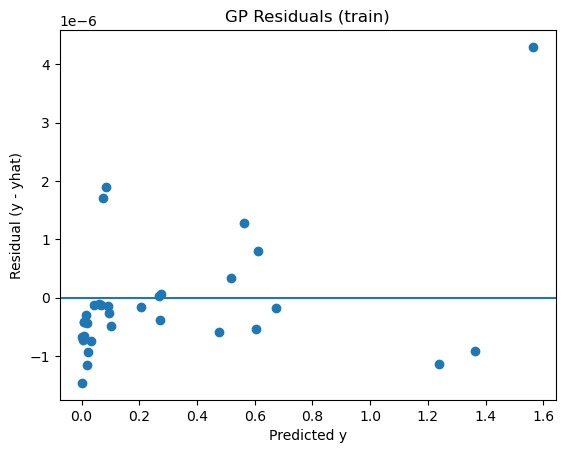

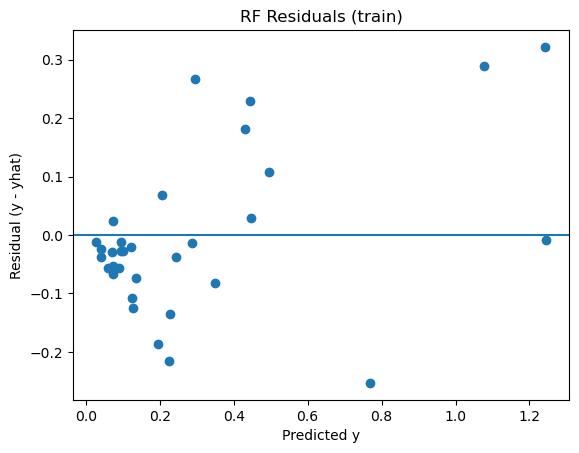

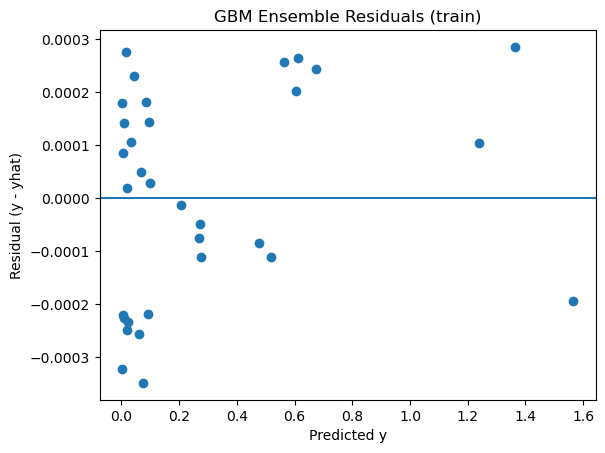

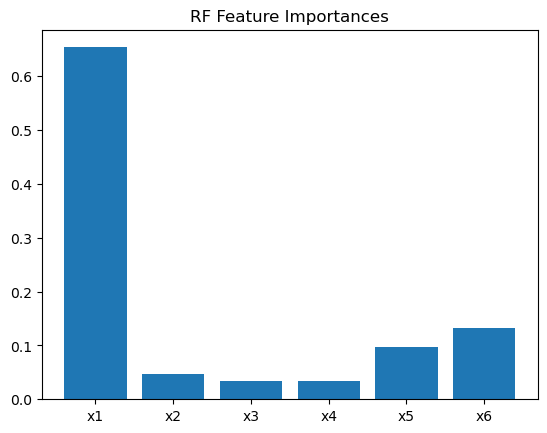

[DIAG] Distance of proposed x_next to nearest existing sample: 0.5573305430372563


In [6]:
# ============================================================
# 4) DIAGNOSTICS
# ============================================================

# In-sample predicted vs observed (quick sanity check)
mu_gp_train_s, _ = gp.predict(Xs, return_std=True)
mu_gp_train = y_scaler.inverse_transform(mu_gp_train_s.reshape(-1, 1)).ravel()

mu_rf_train = rf.predict(X)
mu_gbm_train = np.mean(np.stack([m.predict(X) for m in gbm_ens], axis=0), axis=0)

def plot_pred_vs_obs(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel("Observed y")
    plt.ylabel("Predicted y")
    plt.title(title)
    plt.show()

plot_pred_vs_obs(y, mu_gp_train, "GP: Predicted vs Observed (train)")
plot_pred_vs_obs(y, mu_rf_train, "RF: Predicted vs Observed (train)")
plot_pred_vs_obs(y, mu_gbm_train, "GBM Ensemble: Predicted vs Observed (train)")

# Residual plots
def plot_residuals(y_true, y_pred, title):
    res = y_true - y_pred
    plt.figure()
    plt.scatter(y_pred, res)
    plt.axhline(0)
    plt.xlabel("Predicted y")
    plt.ylabel("Residual (y - yhat)")
    plt.title(title)
    plt.show()

plot_residuals(y, mu_gp_train, "GP Residuals (train)")
plot_residuals(y, mu_rf_train, "RF Residuals (train)")
plot_residuals(y, mu_gbm_train, "GBM Ensemble Residuals (train)")

# RF Feature importances
plt.figure()
plt.bar(np.arange(d), rf.feature_importances_)
plt.xticks(np.arange(d), [f"x{i+1}" for i in range(d)])
plt.title("RF Feature Importances")
plt.show()

print("[DIAG] Distance of proposed x_next to nearest existing sample:", x_next_dist)



In [7]:
# ============================================================
# 5) OUTPUT
# ============================================================
# Single-line output for tutor submission:
x_next_line = " ".join([f"{v:.6f}" for v in x_next])
print("\n=== NEXT X (submit this one line) ===")
print(x_next_line)

# Optional: save it for convenience
np.save("F7_week04_next_x.npy", x_next.reshape(1, -1))
print("\n[OUTPUT] Saved: F7_week04_next_x.npy")


=== NEXT X (submit this one line) ===
0.021523 0.981860 0.758164 0.537874 0.262140 0.730442

[OUTPUT] Saved: F7_week04_next_x.npy
